In [ ]:
%cd ..
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive0

/
Mounted at /content/gdrive


In [ ]:
!cp mydrive/Jamun/Jamun.zip ./

In [ ]:
!unzip ../Jamun.zip -d /content/

Archive:  ../Jamun.zip
   creating: /content/test/BacterialSpot/
  inflating: /content/test/BacterialSpot/Bacterial_Spot (321).jpg  
  inflating: /content/test/BacterialSpot/Bacterial_Spot (322).jpg  
  inflating: /content/test/BacterialSpot/Bacterial_Spot (323).jpg  
  inflating: /content/test/BacterialSpot/Bacterial_Spot (324).jpg  
  inflating: /content/test/BacterialSpot/Bacterial_Spot (325).jpg  
  inflating: /content/test/BacterialSpot/Bacterial_Spot (326).jpg  
  inflating: /content/test/BacterialSpot/Bacterial_Spot (327).jpg  
  inflating: /content/test/BacterialSpot/Bacterial_Spot (328).jpg  
  inflating: /content/test/BacterialSpot/Bacterial_Spot (329).jpg  
  inflating: /content/test/BacterialSpot/Bacterial_Spot (330).jpg  
  inflating: /content/test/BacterialSpot/Bacterial_Spot (331).jpg  
  inflating: /content/test/BacterialSpot/Bacterial_Spot (332).jpg  
  inflating: /content/test/BacterialSpot/Bacterial_Spot (333).jpg  
  inflating: /content/test/BacterialSpot/Bacterial_

In [ ]:
!pip install -q torchinfo
!git clone https://github.com/mrdbourke/pytorch-deep-learning
!mv pytorch-deep-learning/going_modular .
!rm -rf pytorch-deep-learning

Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4410, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 4410 (delta 5), reused 2 (delta 2), pack-reused 4400 (from 2)
Receiving objects: 100% (4410/4410), 764.18 MiB | 28.98 MiB/s, done.
Resolving deltas: 100% (2661/2661), done.
Updating files: 100% (248/248), done.


In [ ]:
import matplotlib.pyplot as plt
import torch
import torchvision
from torch import nn
from torchvision import transforms
from torchinfo import summary
from going_modular.going_modular import data_setup, engine
import os
import zipfile
from pathlib import Path
import requests
from typing import List, Tuple
from PIL import Image

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
weights = torchvision.models.SqueezeNet1_0_Weights.DEFAULT
model = torchvision.models.squeezenet1_0(weights=weights).to(device)
auto_transforms = weights.transforms()
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir="/content/train/",
                                                                               test_dir="/content/test/",
                                                                               transform=auto_transforms, # perform same data transforms on our own data as the pretrained model
                                                                               batch_size=32) # set mini-batch size to 32

Downloading: "https://download.pytorch.org/models/squeezenet1_0-b66bff10.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_0-b66bff10.pth


100%|██████████| 4.78M/4.78M [00:00<00:00, 72.3MB/s]


In [ ]:
for param in model.features.parameters():
    param.requires_grad = False

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
output_shape = len(class_names)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Conv2d(512, len(class_names), kernel_size=1),
    nn.ReLU(inplace=True),
    nn.AdaptiveAvgPool2d((1, 1))).to(device)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
results = engine.train(model=model,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=15,
                       device=device)

  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.8110 | train_acc: 0.7435 | test_loss: 0.3421 | test_acc: 0.8984
Epoch: 2 | train_loss: 0.2155 | train_acc: 0.9454 | test_loss: 0.2068 | test_acc: 0.9512
Epoch: 3 | train_loss: 0.1392 | train_acc: 0.9710 | test_loss: 0.1437 | test_acc: 0.9746
Epoch: 4 | train_loss: 0.1013 | train_acc: 0.9773 | test_loss: 0.0987 | test_acc: 0.9883
Epoch: 5 | train_loss: 0.0784 | train_acc: 0.9894 | test_loss: 0.0788 | test_acc: 0.9902
Epoch: 6 | train_loss: 0.0623 | train_acc: 0.9924 | test_loss: 0.0633 | test_acc: 0.9902
Epoch: 7 | train_loss: 0.0507 | train_acc: 0.9955 | test_loss: 0.0619 | test_acc: 0.9883
Epoch: 8 | train_loss: 0.0434 | train_acc: 0.9934 | test_loss: 0.0441 | test_acc: 0.9980
Epoch: 9 | train_loss: 0.0371 | train_acc: 0.9975 | test_loss: 0.0401 | test_acc: 0.9980
Epoch: 10 | train_loss: 0.0318 | train_acc: 0.9995 | test_loss: 0.0349 | test_acc: 1.0000
Epoch: 11 | train_loss: 0.0288 | train_acc: 0.9980 | test_loss: 0.0279 | test_acc: 1.0000
Epoch: 12 | train_l

In [ ]:
class_names

['BacterialSpot',
 'BrownBlight',
 'Dry',
 'Healthy',
 'PowderyMildew',
 'SootyMold',
 'WaspDisease']

In [ ]:
f = open("results.txt", "a")
f.write(str(results))
f.close()

In [ ]:
mv results.txt /content/

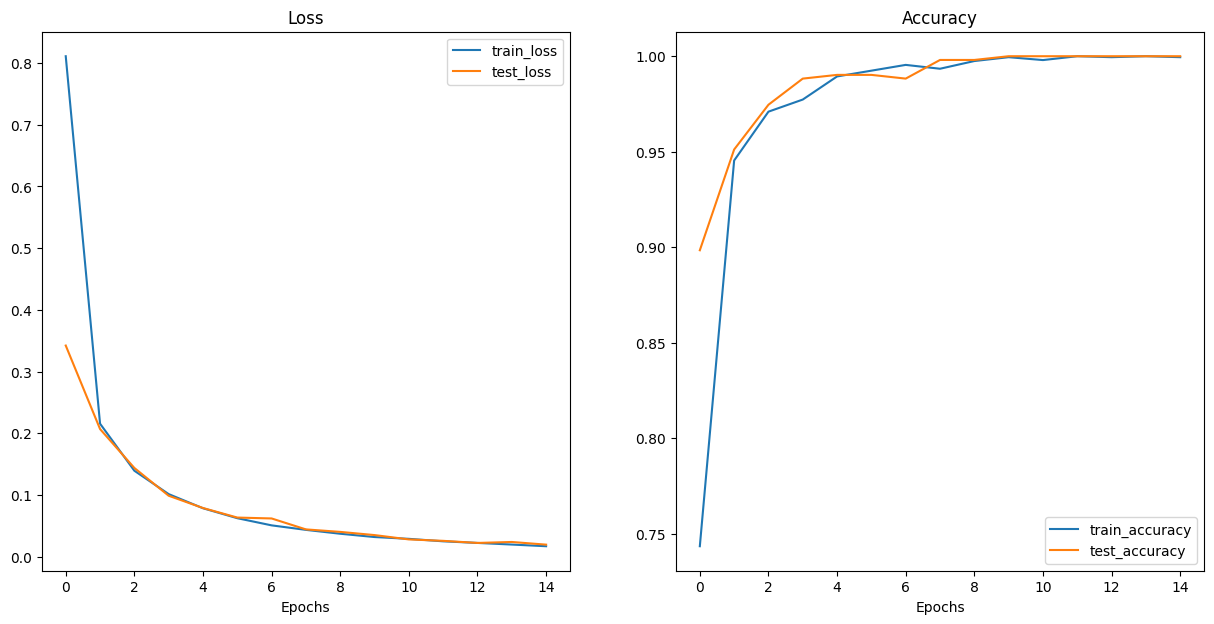

In [ ]:
with open("helper_functions.py", "wb") as f:
    import requests
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    f.write(request.content)
from helper_functions import plot_loss_curves

plot_loss_curves(results)

In [ ]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device):
    img = Image.open(image_path)
    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
    model.to(device)
    model.eval()
    with torch.inference_mode():
      transformed_image = image_transform(img).unsqueeze(dim=0)
      target_image_pred = model(transformed_image.to(device))
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)
    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False);

In [ ]:
torch.save(model, "/content/squeeze.pt")

In [ ]:
the_model = torch.load('/content/squeeze.pt', weights_only=False)

0.12943816184997559 
0.025628328323364258 
0.016185522079467773 
0.020881175994873047 
0.016025781631469727 


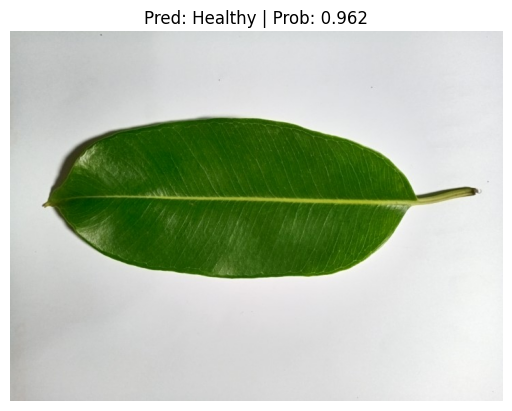

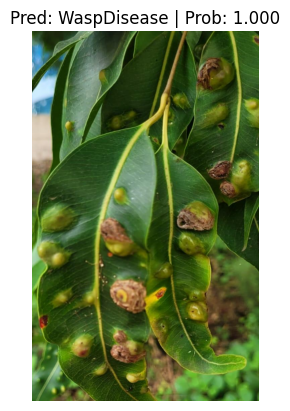

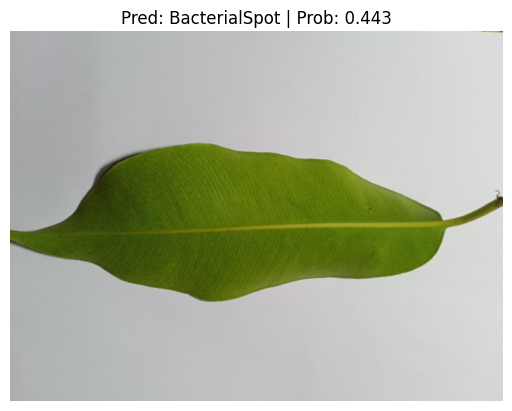

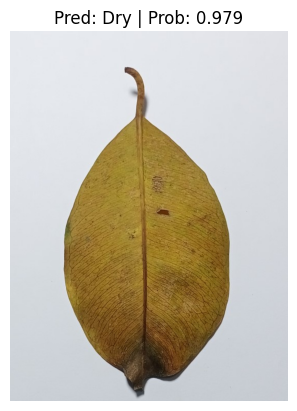

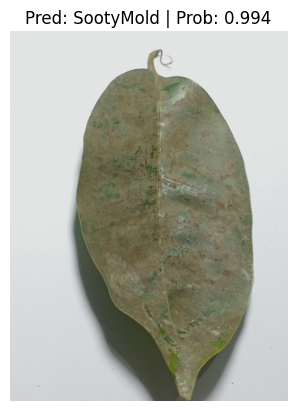

In [ ]:
fruits =  [["/content/train/Healthy/Healthy (150).jpg", ""],
           ["/content/test/WaspDisease/img66.jpg", ""],
            ["/content/test/Healthy/Healthy (322).jpg", ""],
            ["/content/train/Dry/Dry (101).jpg", ""],
                       ["/content/train/SootyMold/Sooty_Mold (115).jpg", ""],

           ]


import time
for i in fruits:
  n = time.time()
  pred_and_plot_image(model=the_model,
                        image_path=i[0],
                        class_names=class_names,
                        image_size=(224, 224))
  print(time.time()-n, i[1])